<a href="https://colab.research.google.com/github/Series-Parallel/Machine_in_Deep_Learning/blob/main/Early_Exit_Monocular_Depth_Estimation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


resnet-18


In [ ]:
class ResNet18Encoder(nn.Module):
    def __init__(self):
        super().__init__()

        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # Initial layers
        self.initial = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu
        )

        self.maxpool = resnet.maxpool

        # Encoder stages
        self.layer1 = resnet.layer1   # 64 channels
        self.layer2 = resnet.layer2   # 128 channels
        self.layer3 = resnet.layer3   # 256 channels
        self.layer4 = resnet.layer4   # 512 channels

    def forward(self, x):

        x0 = self.initial(x)      # H/2
        x1 = self.maxpool(x0)     # H/4

        x2 = self.layer1(x1)      # H/4
        x3 = self.layer2(x2)      # H/8
        x4 = self.layer3(x3)      # H/16
        x5 = self.layer4(x4)      # H/32

        return x0, x2, x3, x4, x5

In [ ]:
encoder = ResNet18Encoder().to(device)

dummy = torch.randn(1, 3, 224, 224).to(device)

features = encoder(dummy)

for i, f in enumerate(features):
    print(f"Feature {i}: {f.shape}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 177MB/s]


Feature 0: torch.Size([1, 64, 112, 112])
Feature 1: torch.Size([1, 64, 56, 56])
Feature 2: torch.Size([1, 128, 28, 28])
Feature 3: torch.Size([1, 256, 14, 14])
Feature 4: torch.Size([1, 512, 7, 7])


decoder!!


In [ ]:
class UpBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels + skip_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x, skip):

        x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)

        x = torch.cat([x, skip], dim=1)

        x = self.conv(x)

        return x

In [ ]:
class DepthEstimationModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = ResNet18Encoder()

        self.up1 = UpBlock(512, 256, 256)
        self.up2 = UpBlock(256, 128, 128)
        self.up3 = UpBlock(128, 64, 64)
        self.up4 = UpBlock(64, 64, 32)

        self.final_conv = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):

        x0, x2, x3, x4, x5 = self.encoder(x)

        d1 = self.up1(x5, x4)
        d2 = self.up2(d1, x3)
        d3 = self.up3(d2, x2)
        d4 = self.up4(d3, x0)

        depth = self.final_conv(d4)

        depth = F.interpolate(
          depth,
          scale_factor=2,
          mode='bilinear',
          align_corners=False
            )

        return depth

In [ ]:
model = DepthEstimationModel().to(device)

dummy = torch.randn(1, 3, 224, 224).to(device)

output = model(dummy)

print(output.shape)

torch.Size([1, 1, 224, 224])


testing this model on the real image


In [7]:
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms

In [8]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [9]:
from google.colab import files

uploaded = files.upload()

Saving WhatsApp Image 2024-04-18 at 14.20.51_95d91a06.jpg to WhatsApp Image 2024-04-18 at 14.20.51_95d91a06.jpg


In [13]:
from PIL import ImageOps

image = Image.open(next(iter(uploaded)))
image = ImageOps.exif_transpose(image).convert("RGB")

input_tensor = transform(image).unsqueeze(0).to(device)

print(input_tensor.shape)

torch.Size([1, 3, 224, 224])


In [14]:
model.eval()

with torch.no_grad():
    pred_depth = model(input_tensor)

print(pred_depth.shape)

torch.Size([1, 1, 224, 224])


visualizing how the image looks, sounds interesting!


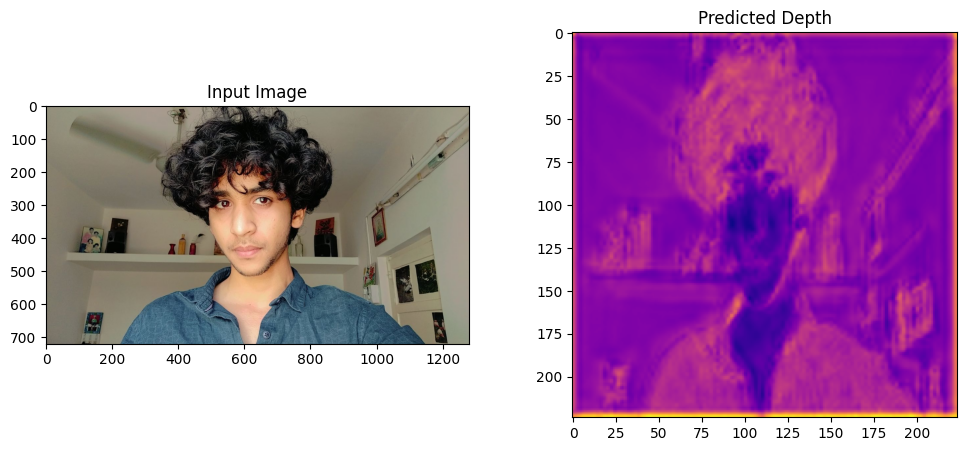

In [15]:
depth_map = pred_depth.squeeze().cpu().numpy()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Input Image")

plt.subplot(1,2,2)
plt.imshow(depth_map, cmap='plasma')
plt.title("Predicted Depth")

plt.show()